# Simulation of the integer comparison system

The goal of this notebook is to simulate our PEN-DNA system for the integer comparison, for n=3 bits.

In [1]:
import matplotlib.pyplot as plt
from scipy.integrate import odeint
import numpy as np
import pandas as pd
from tqdm import tqdm  # for progress bar

from strands import Signal, Drain, Template
from PEN_simulation import System

In [2]:
def create_system(InputA,InputB,temperature=39, sodium=0.07, magnesium=0.0125):
    """Create the system comparing two inputs of three bits"""
    #Intermediate signals
    alpha0=Signal(name="alpha0", IsDrained=True, protected=False, sequence='TTCAGTGTAGGG')
    alpha1=Signal(name="alpha1", IsDrained=True, protected=False,sequence='TAGACAGATCCG')
    alpha2=Signal(name="alpha2", IsDrained=True, protected=False, sequence='TTAGTGGTGTTG')
    delta0=Signal(name="delta0", protected=False, sequence='TAGCGAGTTGTG')
    delta1=Signal(name="delta1", protected=False,sequence='TTTGTCGATCAA')
    delta2=Signal(name="delta2", protected=False, sequence='TCAAAGGGAGAA')
    gamma=Signal(name="gamma", protected=False, sequence='CATTCTCGACAG')

    #Input signals
    input_a00=Signal(name="input_a00", protected=False, sequence='ACGTTGATGTTT')
    input_b00=Signal(name="input_b00", protected=False,sequence='TACGGACGTCTA')
    input_a10=Signal(name="input_a10", protected=False, sequence='CGATGTAACTCG')
    input_b10=Signal(name="input_b10", protected=False, sequence='GGAATCTACGAG')
    input_a20=Signal(name="input_a20", protected=False, sequence='TCGGACATAATG')
    input_b20=Signal(name="input_b20", protected=False, sequence='TTGGGTCAATGT')

    #Drains
    drain0=Drain("drain0", input=alpha0, sequence='CCCTACACTGAAAA')
    drain1=Drain("drain1", input=alpha1, sequence='CGGATCTGTCTAAA')
    drain2=Drain("drain2", input=alpha2, sequence='CAACACCACTAAAA')

    #Input Templates
    tmp_input_a00_delta0=Template(name="input_a00_delta0", sequence='CACAACTCGCTAACCTGACTCAAACATCAACGT', input=input_a00, output=delta0, loading=True, protected=False, nick='nbI')
    tmp_input_a10_delta1=Template(name="input_a10_delta1", sequence='TTGATCGACAAAAACTGACTCCGAGTTACATCG', input=input_a10, output=delta1, loading=True, protected=False, nick='nbI')
    tmp_input_a20_delta2=Template(name="input_a20_delta2", sequence='TTCTCCCTTTGAACTAGACTCCATTATGTCCGA', input=input_a20, output=delta2, loading=True, protected=False, nick='nbI')

    tmp_input_b00_alpha0=Template(name="input_b00_alpha0", sequence='CCCTACACTGAATAATGACTCTAGACGTCCGTA', input=input_b00,output=alpha0, loading=True, protected=False, nick='nbI')
    tmp_input_b10_alpha1=Template(name="input_b10_alpha1", sequence='CGGATCTGTCTATGCTGACTCCTCGTAGATTCC', input=input_b10,output=alpha1, loading=True, protected=False, nick='nbI')
    tmp_input_b20_alpha2=Template(name="input_b20_alpha2", sequence='CAACACCACTAACTAGGACTCACATTGACCCAA', input=input_b20,output=alpha2, loading=True, protected=False, nick='nbI')

    #Intermediate Templates
    tmp_alpha0_gamma=Template(name="alpha0_gamma", sequence='CTGTCGAGAATGCCCTACACTG', input=alpha0, output=gamma, truncated=True, protected=True, loading=False, concentration=10, nick='bsmI')
    tmp_alpha1_gamma=Template(name="alpha1_gamma", sequence='CTGTCGAGAATGCGGATCTGTC',input=alpha1, output=gamma, truncated=True, protected=True, loading=False, concentration=10, nick='bsmI')
    tmp_alpha2_gamma=Template(name="alpha2_gamma", sequence='CTGTCGAGAATGCAACACCACT', input=alpha2, output=gamma, truncated=True, protected=True, loading=False, concentration=10, nick='bsmI')

    tmp_delta0_drain0=Template(name="delta0_drain0", sequence='TTCAGTGTAGGGTTTATTGACTCCACAACTCGC', input=delta0,output=drain0,protected=True, loading=True, concentration=10, nick='nbI')
    tmp_delta1_drain1=Template(name="delta1_drain1", sequence='TAGACAGATCCGTTGTAAGACTCTTGATCGACA', input=delta1,output=drain1,protected=True, loading=True, concentration=10, nick='nbI')
    tmp_delta2_drain2=Template(name="delta2_drain2", sequence='TTAGTGGTGTTGTTACGTGACTCTTCTCCCTTT', input=delta2,output=drain2,protected=True, loading=True, concentration=10, nick='nbI')

    tmp_delta2_delta1=Template(name="delta2_delta1", sequence='TTGATCGACAAATTACGACTCTTCTCCCTTT', input=delta2,output=delta1,protected=True, loading=True, concentration=10, nick='nbI')
    tmp_delta1_delta0=Template(name="delta1_delta0", sequence='CACAACTCGCTACCCTGACTCTTGATCGACA', input=delta1,output=delta0,protected=True, loading=True, concentration=10, nick='nbI')

    #Concentrations of input A
    if InputA[0]=='0':
        input_a20.concentration=10
    else :
        tmp_input_b20_alpha2.concentration=10
    if InputA[1]=='0':
        input_a10.concentration=10
    else :
        tmp_input_b10_alpha1.concentration=10
    if InputA[2]=='0':
        input_a00.concentration=10
    else :
        tmp_input_b00_alpha0.concentration=10

    #Concentrations if input B
    if InputB[0]=='0':
        input_b20.concentration=10
    else :
        tmp_input_a20_delta2.concentration=10
    if InputB[1]=='0':
        input_b10.concentration=10
    else :
        tmp_input_a10_delta1.concentration=10
    if InputB[2]=='0':
        input_b00.concentration=10
    else :
        tmp_input_a00_delta0.concentration=10

    #create the system
    syst=System(temperature=temperature, sodium=sodium, magnesium=magnesium)
    syst.add_signal(gamma)
    syst.add_signal(alpha0)
    syst.add_signal(alpha1)
    syst.add_signal(alpha2)
    syst.add_signal(delta0)
    syst.add_signal(delta1)
    syst.add_signal(delta2)
    syst.add_signal(input_a00)
    syst.add_signal(input_a10)
    syst.add_signal(input_a20)
    syst.add_signal(input_b00)
    syst.add_signal(input_b10)
    syst.add_signal(input_b20)

    syst.add_drain(drain0)
    syst.add_drain(drain1)
    syst.add_drain(drain2)

    syst.add_template(tmp_alpha0_gamma)
    syst.add_template(tmp_alpha1_gamma)
    syst.add_template(tmp_alpha2_gamma)
    syst.add_template(tmp_delta0_drain0)
    syst.add_template(tmp_delta1_drain1)
    syst.add_template(tmp_delta2_drain2)
    syst.add_template(tmp_input_a00_delta0)
    syst.add_template(tmp_input_a10_delta1)
    syst.add_template(tmp_input_a20_delta2)
    syst.add_template(tmp_input_b00_alpha0)
    syst.add_template(tmp_input_b10_alpha1)
    syst.add_template(tmp_input_b20_alpha2)
    syst.add_template(tmp_delta2_delta1)
    syst.add_template(tmp_delta1_delta0)

    syst.associate_index()
    syst.update_dicts()
    return syst


def create_system_small(InputA,InputB,temperature=39, sodium=0.07, magnesium=0.0125):
    """Create the system comparing two inputs of two bits"""
    #Intermediate signals
    alpha0=Signal(name="alpha0", IsDrained=True, protected=False, sequence='TTCAGTGTAGGG')
    alpha1=Signal(name="alpha1", IsDrained=True, protected=False,sequence='TAGACAGATCCG')
    delta0=Signal(name="delta0", protected=False, sequence='TAGCGAGTTGTG')
    delta1=Signal(name="delta1", protected=False,sequence='TTTGTCGATCAA')
    gamma=Signal(name="gamma", protected=False, sequence='CATTCTCGACAG')

    #Input signals
    input_a00=Signal(name="input_a00", protected=False, sequence='ACGTTGATGTTT')
    input_b00=Signal(name="input_b00", protected=False,sequence='TACGGACGTCTA')
    input_a10=Signal(name="input_a10", protected=False, sequence='CGATGTAACTCG')
    input_b10=Signal(name="input_b10", protected=False, sequence='GGAATCTACGAG')

    #Drains
    drain0=Drain("drain0", input=alpha0, sequence='CCCTACACTGAAAA')
    drain1=Drain("drain1", input=alpha1, sequence='CGGATCTGTCTAAA')

    #Input Templates
    tmp_input_a00_delta0=Template(name="input_a00_delta0", sequence='CACAACTCGCTAACCTGACTCAAACATCAACGT', input=input_a00, output=delta0, loading=True, protected=False, nick='nbI')
    tmp_input_a10_delta1=Template(name="input_a10_delta1", sequence='TTGATCGACAAAAACTGACTCCGAGTTACATCG', input=input_a10, output=delta1, loading=True, protected=False, nick='nbI')

    tmp_input_b00_alpha0=Template(name="input_b00_alpha0", sequence='CCCTACACTGAATAATGACTCTAGACGTCCGTA', input=input_b00,output=alpha0, loading=True, protected=False, nick='nbI')
    tmp_input_b10_alpha1=Template(name="input_b10_alpha1", sequence='CGGATCTGTCTATGCTGACTCCTCGTAGATTCC', input=input_b10,output=alpha1, loading=True, protected=False, nick='nbI')

    #Intermediate Templates
    tmp_alpha0_gamma=Template(name="alpha0_gamma", sequence='CTGTCGAGAATGCCCTACACTG', input=alpha0, output=gamma, truncated=True, protected=True, loading=False, concentration=10, nick='bsmI')
    tmp_alpha1_gamma=Template(name="alpha1_gamma", sequence='CTGTCGAGAATGCGGATCTGTC',input=alpha1, output=gamma, truncated=True, protected=True, loading=False, concentration=10, nick='bsmI')

    tmp_delta0_drain0=Template(name="delta0_drain0", sequence='TTCAGTGTAGGGTTTATTGACTCCACAACTCGC', input=delta0,output=drain0,protected=True, loading=True, concentration=10, nick='nbI')
    tmp_delta1_drain1=Template(name="delta1_drain1", sequence='TAGACAGATCCGTTGTAAGACTCTTGATCGACA', input=delta1,output=drain1,protected=True, loading=True, concentration=10, nick='nbI')

    tmp_delta1_delta0=Template(name="delta1_delta0", sequence='CACAACTCGCTACCCTGACTCTTGATCGACA', input=delta1,output=delta0,protected=True, loading=True, concentration=10, nick='nbI')

    #Concentrations of input A
    if InputA[0]=='0':
        input_a10.concentration=10
    else :
        tmp_input_b10_alpha1.concentration=10
    if InputA[1]=='0':
        input_a00.concentration=10
    else :
        tmp_input_b00_alpha0.concentration=10

    #Concentrations if input B
    if InputB[0]=='0':
        input_b10.concentration=10
    else :
        tmp_input_a10_delta1.concentration=10
    if InputB[1]=='0':
        input_b00.concentration=10
    else :
        tmp_input_a00_delta0.concentration=10

    #create the system
    syst=System(temperature=temperature, sodium=sodium, magnesium=magnesium)
    syst.add_signal(gamma)
    syst.add_signal(alpha0)
    syst.add_signal(alpha1)
    syst.add_signal(delta0)
    syst.add_signal(delta1)
    syst.add_signal(input_a00)
    syst.add_signal(input_a10)
    syst.add_signal(input_b00)
    syst.add_signal(input_b10)

    syst.add_drain(drain0)
    syst.add_drain(drain1)

    syst.add_template(tmp_alpha0_gamma)
    syst.add_template(tmp_alpha1_gamma)
    syst.add_template(tmp_delta0_drain0)
    syst.add_template(tmp_delta1_drain1)
    syst.add_template(tmp_input_a00_delta0)
    syst.add_template(tmp_input_a10_delta1)
    syst.add_template(tmp_input_b00_alpha0)
    syst.add_template(tmp_input_b10_alpha1)
    syst.add_template(tmp_delta1_delta0)

    syst.associate_index()
    syst.update_dicts()
    return syst

## Figures of our two examples (for n=2)

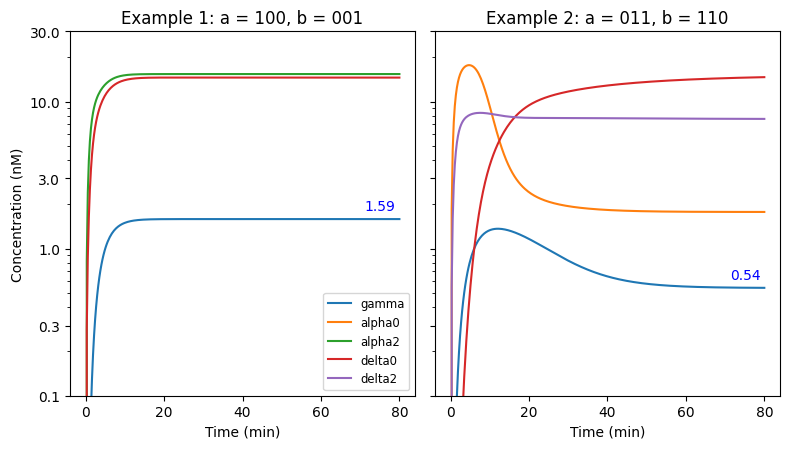

In [7]:
# Simulation settings
temperature = 45
t = np.linspace(0, 80*60, 301)

# Define input pairs
input_pairs = [
    ('100', '001'),
    ('011', '110')
]

# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(8, 5), sharey=True)

for i, (InputA, InputB) in enumerate(input_pairs):
    syst = create_system(InputA, InputB)
    syst.temperature = temperature
    y = syst.solve_system(t)

    ax = axes[i]
    ax.plot(t / 60, y[:, syst.find_index('gamma', 'alone')], label='gamma')
    ax.plot(t / 60, y[:, syst.find_index('alpha0', 'alone')], label='alpha0')
    ax.plot(t / 60, y[:, syst.find_index('alpha2', 'alone')], label='alpha2')
    ax.plot(t / 60, y[:, syst.find_index('delta0', 'alone')], label='delta0')
    ax.plot(t / 60, y[:, syst.find_index('delta2', 'alone')], label='delta2')

    # Set logarithmic scale with a reasonable range
    ax.set_yscale('log')
    ax.set_ylim(0.1, 30)  # Adjust lower limit to avoid tiny/zero values

    # Optional: custom ticks for better readability
    ax.set_yticks([0.1, 0.3, 1, 3, 10, 30])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())
    
    ax.set_xlabel('Time (min)')
    if i == 0:
        ax.set_ylabel('Concentration (nM)')
    ax.set_title(f'Example {i+1}: a = {InputA}, b = {InputB}')
    if i == 0:
        ax.legend(fontsize='small')

    # Add tag for final gamma value
    final_t = t[-1] / 60  # time in minutes at last point
    gamma_final = y[-1, syst.find_index('gamma', 'alone')]
    ax.text(final_t - 1, gamma_final * 1.1, f'{gamma_final:.2f}', fontsize=10, va='bottom', ha='right', color='blue')


    syst.unmalloc()

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('examples.pdf')
plt.show()


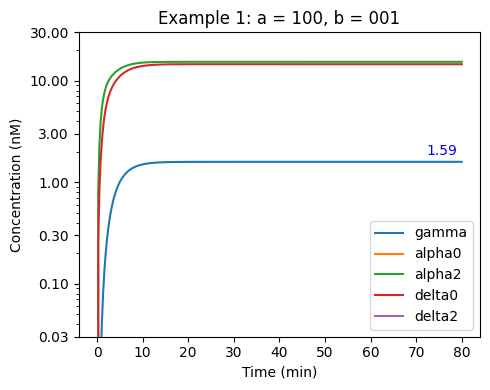

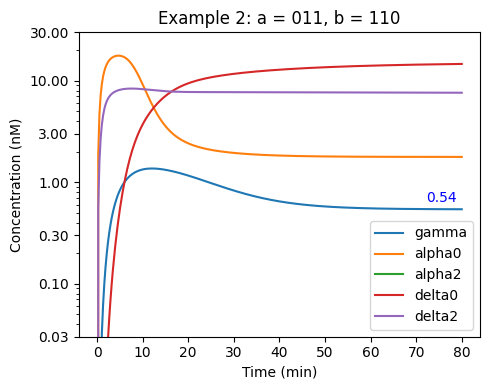

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Simulation settings
temperature = 45
t = np.linspace(0, 80 * 60, 301)

# Define input pairs
input_pairs = [
    ('100', '001'),
    ('011', '110')
]

# Loop over each input pair and create a separate figure
for i, (InputA, InputB) in enumerate(input_pairs):
    fig, ax = plt.subplots(figsize=(5, 4))

    syst = create_system(InputA, InputB)
    syst.temperature = temperature
    y = syst.solve_system(t)

    ax.plot(t / 60, y[:, syst.find_index('gamma', 'alone')], label='gamma')
    ax.plot(t / 60, y[:, syst.find_index('alpha0', 'alone')], label='alpha0')
    ax.plot(t / 60, y[:, syst.find_index('alpha2', 'alone')], label='alpha2')
    ax.plot(t / 60, y[:, syst.find_index('delta0', 'alone')], label='delta0')
    ax.plot(t / 60, y[:, syst.find_index('delta2', 'alone')], label='delta2')

    ax.set_yscale('log')
    ax.set_ylim(0.03, 30)
    ax.set_yticks([0.03,0.1, 0.3, 1, 3, 10, 30])
    ax.get_yaxis().set_major_formatter(plt.ScalarFormatter())

    ax.set_xlabel('Time (min)',fontsize='medium')
    ax.set_ylabel('Concentration (nM)',fontsize='medium')
    ax.set_title(f'Example {i+1}: a = {InputA}, b = {InputB}')

    # Larger legend
    ax.legend(fontsize='medium')

    # Annotate final gamma value
    final_t = t[-1] / 60
    gamma_final = y[-1, syst.find_index('gamma', 'alone')]
    ax.text(final_t - 1, gamma_final * 1.1, f'{gamma_final:.2f}', fontsize=10,
            va='bottom', ha='right', color='blue')

    fig.tight_layout()
    fig.savefig(f'example_{i+1}.pdf')
    plt.show()

    syst.unmalloc()


## Test for 6 conditions with false hope at some layer

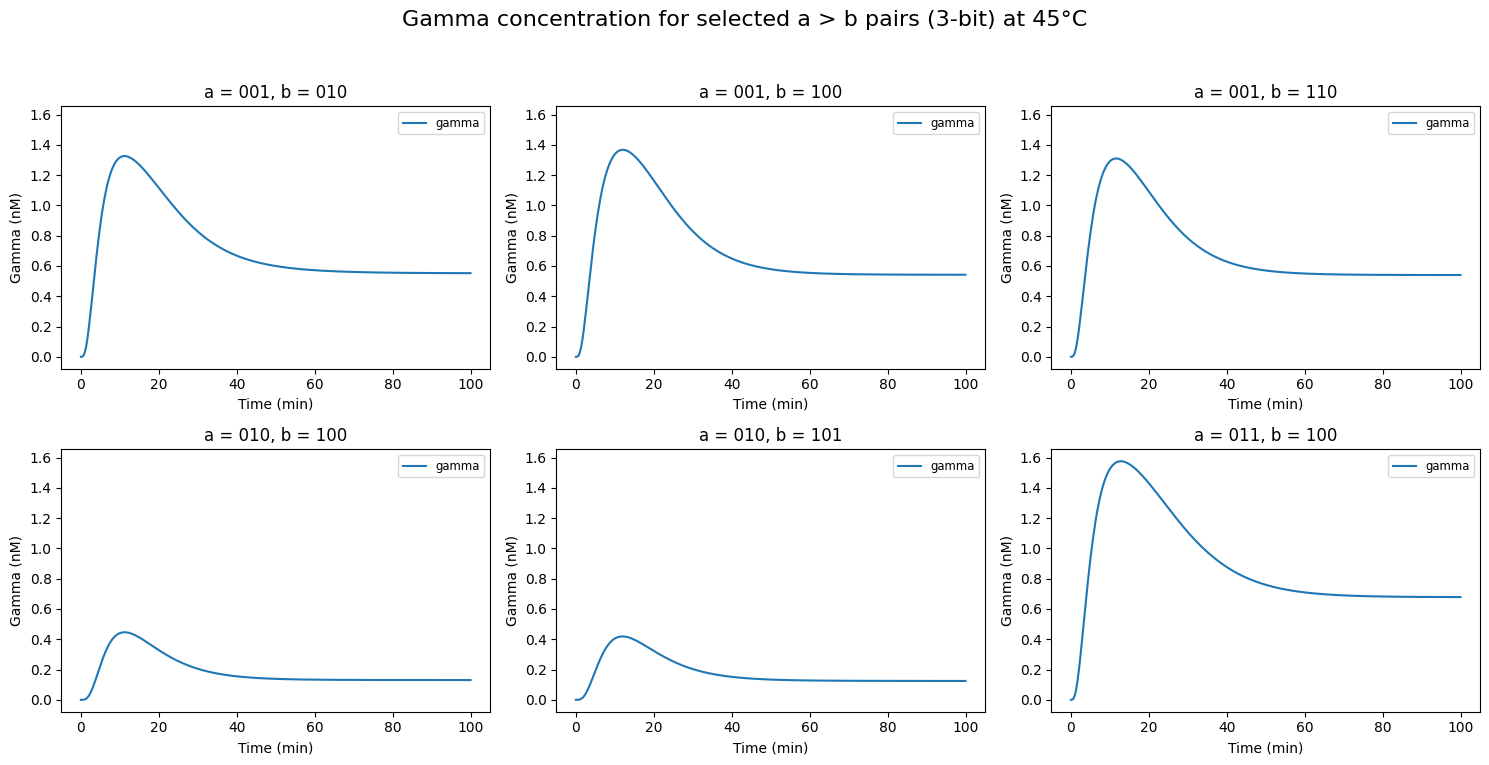

In [ ]:
temperature = 45  # Temperature in Celsius

# List of specific (a, b) input pairs
input_pairs = [
    ('001', '010'),
    ('001', '100'),
    ('001', '110'),
    ('010', '100'),
    ('010', '101'),
    ('011', '100')
]

# Create subplot grid (2 rows x 3 columns)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

t = np.linspace(0, 100*60, 301)
all_gamma = []

# Run all simulations
results = []
for a, b in input_pairs:
    syst = create_system(a, b)
    syst.temperature = temperature
    y = syst.solve_system(t)
    gamma = y[:, syst.find_index('gamma', 'alone')]
    results.append((a, b, gamma))
    all_gamma.append(gamma)
    syst.unmalloc()

# Calculate global y-limits
all_gamma_concat = np.concatenate(all_gamma)
ymin, ymax = all_gamma_concat.min(), all_gamma_concat.max()
y_padding = (ymax - ymin) * 0.05  # 5% padding
ymin -= y_padding
ymax += y_padding

# Plot with shared y-scale
for i, (a, b, gamma) in enumerate(results):
    ax = axes[i]
    ax.plot(t / 60, gamma, label='gamma')
    ax.set_title(f'a = {a}, b = {b}')
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Gamma (nM)')
    ax.set_ylim(ymin, ymax)  # set shared y-limits
    ax.legend(fontsize='small')

# Hide any unused subplot axes
for ax in axes[len(input_pairs):]:
    ax.axis('off')

fig.suptitle(f"Gamma concentration for selected a > b pairs (3-bit) at {temperature}°C", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


## Table of the final concentration of gamma for all possible inputs

In [ ]:
# Generate all 3-bit binary strings
binary_strings = [format(i, '03b') for i in range(8)]

# Prepare an empty 8x8 array to store final gamma concentrations
final_gamma = np.zeros((8, 8))

# Time vector for simulation
t = np.linspace(0, 80*60, 251)
temperature = 45

# Total iterations for progress bar
total_iters = len(binary_strings) * len(binary_strings)

print("Starting simulations...")

with tqdm(total=total_iters) as pbar:
    for i, a in enumerate(binary_strings):
        for j, b in enumerate(binary_strings):
            syst = create_system(a, b)
            syst.temperature = temperature
            y = syst.solve_system(t)
            gamma = y[:, syst.find_index('gamma', 'alone')]
            final_value = gamma[-1]
            final_gamma[i, j] = final_value  # last time point final value
            syst.unmalloc()

            # Print result for this pair
            print(f"Final gamma for a={a}, b={b}: {final_value:.4f}")

            pbar.update(1)

# Convert to DataFrame for nicer CSV output
df = pd.DataFrame(final_gamma, index=binary_strings, columns=binary_strings)
df.index.name = 'Input A \\ Input B'

# Save to CSV
df.to_csv('final_gamma_concentrations.csv')

print("CSV file 'final_gamma_concentrations.csv' saved successfully.")



Starting simulations...


  2%|▏         | 1/64 [01:39<1:44:06, 99.15s/it]

Final gamma for a=000, b=000: 0.0000


  3%|▎         | 2/64 [01:47<46:58, 45.45s/it]  

Final gamma for a=000, b=001: 0.0000


...

Final gamma for a=111, b=101: 1.1283


 98%|█████████▊| 63/64 [13:16<00:10, 10.27s/it]

Final gamma for a=111, b=110: 1.4723


100%|██████████| 64/64 [13:18<00:00, 12.48s/it]

Final gamma for a=111, b=111: 0.0000
CSV file 'final_gamma_concentrations.csv' saved successfully.


In [23]:
def generate_colored_latex_table(df):
    header = list(df.columns)
    rows = list(df.index)

    latex = "\\begin{tabular}{l|" + "c" * len(header) + "}\n"
    latex += "~ & " + " & ".join(header) + " \\\\\n"
    latex += "\\hline\n"

    for a_str in rows:
        row_latex = [str(a_str)]
        a = int(str(a_str), 2)

        for b_str in header:
            b = int(str(b_str), 2)
            val = df.loc[a_str, b_str]

            # Determine cell color based on a vs b
            if a > b:
                color = "lightlime"
            elif a < b:
                color = "lightred"
            else:
                color = "lightgray"

            cell = f"\\cellcolor{{{color}}}{val:.2f}"
            row_latex.append(cell)

        latex += " & ".join(row_latex) + " \\\\\n"

    latex += "\\end{tabular}"
    return latex




# Example usage:
import pandas as pd
df = pd.read_csv('final_gamma_concentrations.csv', index_col=0)
inputsA = list(df.index)
inputsB = list(df.columns)

latex_code = generate_colored_latex_table(df)
print(latex_code)


\begin{tabular}{l|cccccccc}
~ & 000 & 001 & 010 & 011 & 100 & 101 & 110 & 111 \\
\hline
0 & \cellcolor{lightgray}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 \\
1 & \cellcolor{lightlime}1.47 & \cellcolor{lightgray}0.00 & \cellcolor{lightred}0.56 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.54 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.54 & \cellcolor{lightred}0.00 \\
10 & \cellcolor{lightlime}1.14 & \cellcolor{lightlime}1.05 & \cellcolor{lightgray}0.00 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.13 & \cellcolor{lightred}0.12 & \cellcolor{lightred}0.00 & \cellcolor{lightred}0.00 \\
11 & \cellcolor{lightlime}1.91 & \cellcolor{lightlime}1.14 & \cellcolor{lightlime}1.47 & \cellcolor{lightgray}0.00 & \cellcolor{lightred}0.68 & \cellcolor{lightred}0.13 & \cellcolor{lightred}0.54 & \cellcolor{lightred}0.00 \\
100 & \cellcolor

We conclude that the worst negative situation is for a=011 and b=100, while the worst positive situation is for a=110 and b=101.
In the following, we decide to focuss on these two cases.

## Study of the consequence of temperature on the worst cases

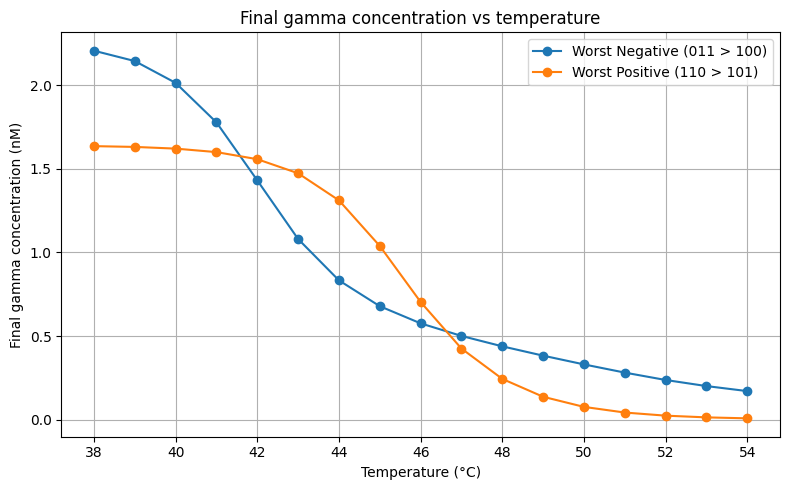

In [5]:
# Define input pairs
cases = {
    'Worst Negative (011 > 100)': ('011', '100'),
    'Worst Positive (110 > 101)': ('110', '101')
}

# Temperature range (°C)
temperatures = np.arange(38, 55, 1)  # from 35°C to 60°C

# Time vector
t = np.linspace(0, 100*60, 301)

# Store results
results = {label: [] for label in cases}

# Simulate each case over all temperatures
for label, (a, b) in cases.items():
    for temp in temperatures:
        syst = create_system(a, b)
        syst.temperature = temp
        y = syst.solve_system(t)
        gamma = y[:, syst.find_index('gamma', 'alone')]
        results[label].append(gamma[-1])  # Store final gamma
        syst.unmalloc()

# Plotting
plt.figure(figsize=(8, 5))
for label, gamma_final_values in results.items():
    plt.plot(temperatures, gamma_final_values, marker='o', label=label)

plt.xlabel('Temperature (°C)')
plt.ylabel('Final gamma concentration (nM)')
plt.title('Final gamma concentration vs temperature')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('gamma_vs_temperature.pdf')
plt.show()


## Study of the consequence of template concentration on the worst cases

### Concentration of kT

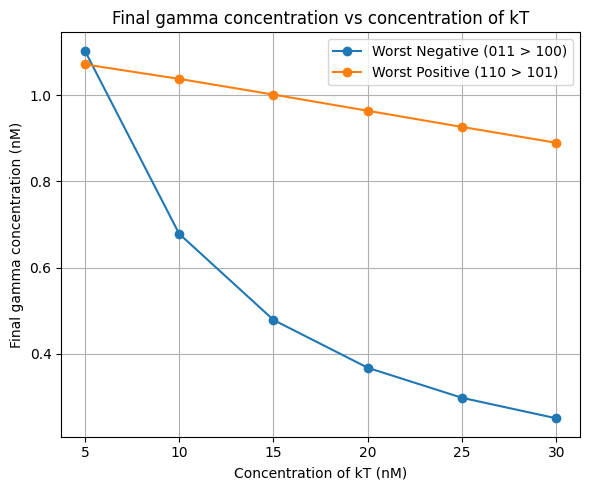

In [6]:
# Define input pairs
cases = {
    'Worst Negative (011 > 100)': ('011', '100'),
    'Worst Positive (110 > 101)': ('110', '101')
}

# Temperature range (°C)
tmp_concentration = np.arange(5, 31, 5)  # from 35°C to 60°C

# Time vector
t = np.linspace(0, 100*60, 301)

# Store results
results = {label: [] for label in cases}

# Simulate each case over all temperatures
for label, (a, b) in cases.items():
    for conc in tmp_concentration:
        syst = create_system(a, b)
        syst.temperature = 45
        for tmp in syst.templates:
            if 'drain' in tmp.output.name:
                tmp.concentration = conc
        y = syst.solve_system(t)
        gamma = y[:, syst.find_index('gamma', 'alone')]
        results[label].append(gamma[-1])  # Store final gamma
        syst.unmalloc()

# Plotting
plt.figure(figsize=(6, 5))
for label, gamma_final_values in results.items():
    plt.plot(tmp_concentration, gamma_final_values, marker='o', label=label)

plt.xlabel('Concentration of kT (nM)')
plt.ylabel('Final gamma concentration (nM)')
plt.title('Final gamma concentration vs concentration of kT')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('gamma_vs_kT.pdf')
plt.show()


### Concentration of cT_Lay

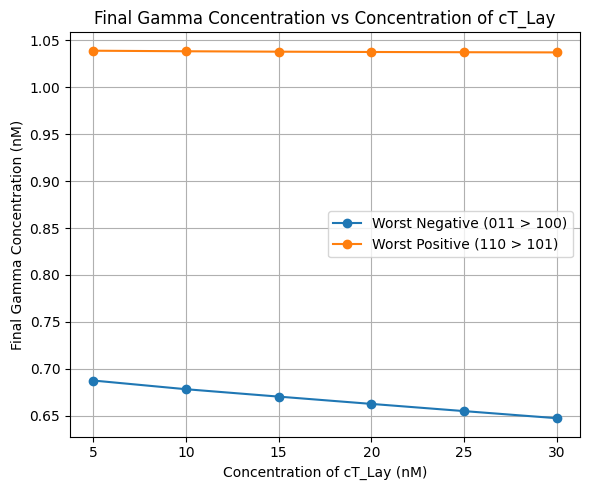

In [ ]:
# Define input pairs
cases = {
    'Worst Negative (011 > 100)': ('011', '100'),
    'Worst Positive (110 > 101)': ('110', '101')
}

# Temperature range (°C)
tmp_concentration = np.arange(5, 31, 5)  # from 35°C to 60°C

# Time vector
t = np.linspace(0, 100*60, 301)

# Store results
results = {label: [] for label in cases}

# Simulate each case over all temperatures
for label, (a, b) in cases.items():
    for conc in tmp_concentration:
        syst = create_system(a, b)
        syst.temperature = 45
        for tmp in syst.templates:
            if 'delta' in tmp.output.name and 'delta' in tmp.input.name:
                tmp.concentration = conc
        y = syst.solve_system(t)
        gamma = y[:, syst.find_index('gamma', 'alone')]
        results[label].append(gamma[-1])  # Store final gamma
        syst.unmalloc()

# Plotting
plt.figure(figsize=(6, 5))
for label, gamma_final_values in results.items():
    plt.plot(tmp_concentration, gamma_final_values, marker='o', label=label)

plt.xlabel('Concentration of cT_Lay (nM)')
plt.ylabel('Final gamma concentration (nM)')
plt.title('Final gamma concentration vs concentration of cT_Lay')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('gamma_vs_cT_Lay.pdf')
plt.show()


## Study of the worst case in case of shorter cT_Rep

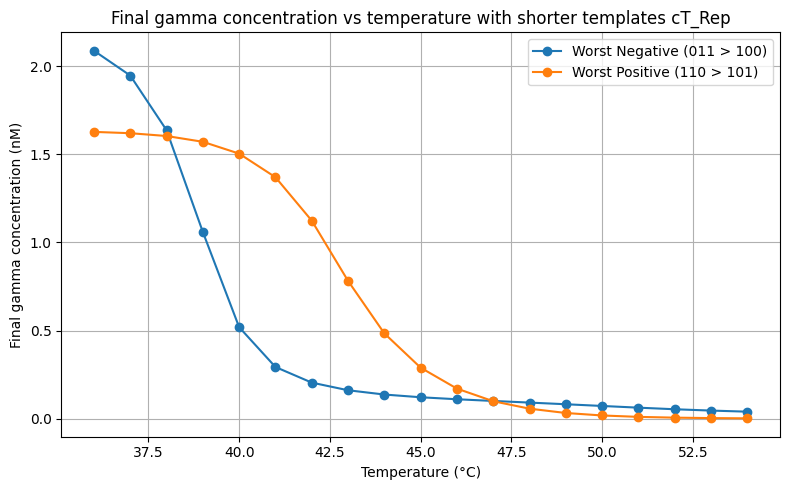

In [4]:
# Define input pairs
cases = {
    'Worst Negative (011 > 100)': ('011', '100'),
    'Worst Positive (110 > 101)': ('110', '101')
}

# Temperature range (°C)
temperatures = np.arange(36, 55, 1) 

# Time vector
t = np.linspace(0, 100*60, 301)

# Store results
results = {label: [] for label in cases}

# Simulate each case over all temperatures
for label, (a, b) in cases.items():
    for temp in temperatures:
        syst = create_system(a, b)
        syst.temperature = temp
        for tmp in syst.templates:
            if 'gamma' in tmp.output.name:
                tmp.sequence = tmp.sequence[0:-1]  # Truncate cT_Rep sequence
        y = syst.solve_system(t)
        gamma = y[:, syst.find_index('gamma', 'alone')]
        results[label].append(gamma[-1])  # Store final gamma
        syst.unmalloc()

# Plotting
plt.figure(figsize=(8, 5))
for label, gamma_final_values in results.items():
    plt.plot(temperatures, gamma_final_values, marker='o', label=label)

plt.xlabel('Temperature (°C)')
plt.ylabel('Final gamma concentration (nM)')
plt.title('Final gamma concentration vs temperature with shorter templates cT_Rep')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig('gamma_vs_temperature_short_cT_Rep.pdf')
plt.show()
